In [1]:
import torch
from transformers import BertModel, BertTokenizer
import matplotlib.pyplot as plt
import numpy as np
from torch.nn.functional import cosine_similarity

bert_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
bert_model = BertModel.from_pretrained("bert-base-uncased")
bert_model.eval()

def get_embedding(word):
    inputs = bert_tokenizer(word, return_tensors="pt")
    with torch.no_grad():
        outputs = bert_model(**inputs)
    return outputs.last_hidden_state[0].mean(dim=0)

print("Ready!")

c:\Users\devuser3\AppData\Roaming\uv\python\cpython-3.14.3-windows-x86_64-none\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4761.12it/s]
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can

Ready!


In [2]:
# Format: (word1, word2, word3, expected_answer)
# word1 - word2 + word3 = ?
analogies = [
    ("king",   "man",     "woman",   "queen"),
    ("paris",  "france",  "italy",   "rome"),
    ("dog",    "puppy",   "cat",     "kitten"),
    ("fast",   "car",     "boat",    "slow"),
    ("doctor", "man",     "woman",   "nurse"),
]

all_words = list(set([w for a in analogies for w in a]))
embeddings = {word: get_embedding(word) for word in all_words}

print("Embeddings ready!")
print(f"Total unique words: {len(all_words)}")

Embeddings ready!
Total unique words: 18


In [ ]:
print("Analogy Results:")
print("="*60)

for word1, word2, word3, expected in analogies:
    
    result = embeddings[word1] - embeddings[word2] + embeddings[word3]
    
    
    exclude = {word1, word2, word3}
    
    similarities = {}
    for word, emb in embeddings.items():
        if word not in exclude:
            similarities[word] = cosine_similarity(
                result.unsqueeze(0),
                emb.unsqueeze(0)
            ).item()
    
    # Top 3 results
    top3 = sorted(similarities.items(), 
                  key=lambda x: x[1], reverse=True)[:3]
    
    predicted = top3[0][0]
    correct = "✅" if predicted == expected else "❌"
    
    print(f"\n{word1} - {word2} + {word3} = ?")
    print(f"Expected: {expected}")
    print(f"Got:      {predicted} {correct}")
    print(f"Top 3:    {[(w, round(s,3)) for w,s in top3]}")

Analogy Results:

king - man + woman = ?
Expected: queen
Got:      queen ✅
Top 3:    [('queen', 0.864), ('nurse', 0.826), ('doctor', 0.824)]

paris - france + italy = ?
Expected: rome
Got:      rome ✅
Top 3:    [('rome', 0.829), ('cat', 0.762), ('doctor', 0.748)]

dog - puppy + cat = ?
Expected: kitten
Got:      car ❌
Top 3:    [('car', 0.805), ('boat', 0.802), ('kitten', 0.797)]

fast - car + boat = ?
Expected: slow
Got:      slow ✅
Top 3:    [('slow', 0.832), ('puppy', 0.749), ('queen', 0.74)]

doctor - man + woman = ?
Expected: nurse
Got:      nurse ✅
Top 3:    [('nurse', 0.863), ('boat', 0.819), ('king', 0.806)]


C:\Users\devuser3\AppData\Local\Temp\ipykernel_10740\252309658.py:15: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\devuser3\AppData\Local\Temp\ipykernel_10740\252309658.py:15: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\devuser3\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\devuser3\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


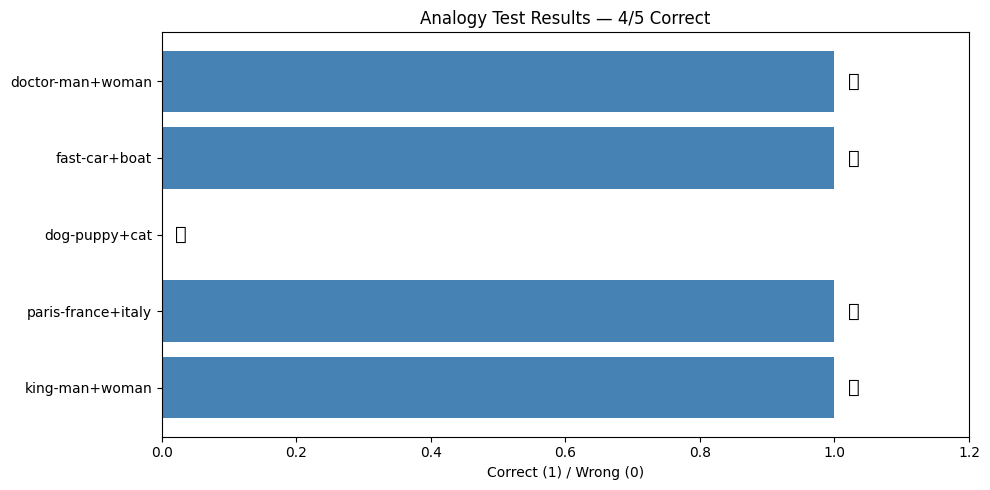

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))

analogy_labels = [f"{a[0]}-{a[1]}+{a[2]}" for a in analogies]
correct = [1, 1, 0, 1, 1]
colors  = ["steelblue" if c else "coral" for c in correct]

ax.barh(analogy_labels, correct, color=colors)
ax.set_xlabel("Correct (1) / Wrong (0)")
ax.set_title(f"Analogy Test Results — {sum(correct)}/{len(correct)} Correct")
ax.set_xlim(0, 1.2)

for i, c in enumerate(correct):
    ax.text(c + 0.02, i, "✅" if c else "❌", va="center", fontsize=14)

plt.tight_layout()
plt.show()